In [1]:
%load_ext cuml.accel
# %run /workspace/alvin/SAR_ML/notebooks/SSR/SSRtransforms_preloaded.py
%run /mnt/d/Users/Admin/Projects/dso/SAR_ML/notebooks/SSR/SSRtransforms_preloaded.py
import os
import re
import copy
import random
from collections import defaultdict
from joblib import Parallel, delayed
from tqdm import tqdm
import pickle
import time

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from cuml.manifold import TSNE, UMAP

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
from torchvision import datasets, transforms, models
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, ConcatDataset, Subset, Dataset

import sys
sys.path.append("/mnt/d/Users/Admin/Projects/dso/learnable_polyphase_sampling/learn_poly_sampling")

from functools import partial
from layers import PolyphaseInvariantDown2D, LPS, get_logits_model
from models.resnet_custom import ResNet18Custom

In [2]:
def set_seed(seed=42):
    """Set all random seeds for reproducibility"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    # Uncomment only if you need 100% determinism and can handle errors
    # torch.use_deterministic_algorithms(True, warn_only=True)
    # os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
    
    os.environ["PYTHONHASHSEED"] = str(seed)

def worker_init_fn(worker_id):
    """DataLoader worker init for reproducibility"""
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

In [3]:
# workspace = "/workspace/alvin/SAR_ML"
workspace = "/mnt/d/Users/Admin/Projects/dso/SAR_ML"

In [4]:
def get_mask_path(img_path, npy_root, mask_root):
    """
    Map a sample path under npy_noscaling_files/... to its corresponding
    mask path under masks/npy_files/...
    """
    img_path = Path(img_path)
    npy_root = Path(npy_root)
    mask_root = Path(mask_root)
    
    rel_path = img_path.relative_to(npy_root)  # e.g. real/2s1/2s1_real_..._b01.npy
    return mask_root / rel_path

In [5]:
meas_ds = DatasetFolderWithPath(
    os.path.join(workspace, "data/DSO/mstar/npy_noscaling_files/real"),
    extensions=(".npy"),
    transform=transforms.Compose([
        Magnitude(),
        LogMapping(c=1000.0),
        NumpyToTensor3Channel()
    ]),
    loader=dso_np_file_loader
)

In [62]:
npy_root = os.path.join(workspace, "data/DSO/mstar/npy_noscaling_files")
mask_root = os.path.join(workspace, "data/DSO/mstar/masks/npy_files")

meas_paths = [s[0] for s in meas_ds.samples]
meas_target_cache = {}

for path in tqdm(meas_paths):
    mask_path = get_mask_path(path, npy_root, mask_root)
    mask = np.load(mask_path)
    meas_target_cache[path] = (mask > 0).astype(np.uint8)

100%|████████████████████████████████████████████████████████████████████████████| 13932/13932 [00:58<00:00, 236.30it/s]


In [75]:
np.unique((mask > 0).astype(np.uint8))

array([0, 1], dtype=uint8)

In [63]:
precomputed_target_meas_ds = DatasetFolderWithPath(
    os.path.join(workspace, "data/DSO/mstar/npy_noscaling_files/real"),
    extensions=(".npy"),
    transform=transforms.Compose([
        Magnitude(),
        LogMapping(c=1000.0),
        MaskedAugmentation(augmentation=identity, fill=0, mask_cache=meas_target_cache),
        NumpyToTensor3Channel()
    ]),
    loader=dso_np_file_loader
)

In [5]:
def obtain_mask_from_tiff_flipped(path, values = [65, 67, 193, 195, 225, 227]):
    with TiffFile(path) as tif:
        mask = tif.pages[3].asarray()
    mask = np.fliplr(mask)
    return np.isin(mask, values)

In [6]:
no_aug_synth_ds = DatasetFolderWithPath(
    "/mnt/d/Users/Admin/Projects/dso/SAR_ML/data/DSO/MSTAR_sim_jul26",
    extensions=(".tif",),
    transform=transforms.Compose([Magnitude(), LogMapping(c=1000.0), NumpyToTensor3Channel()]),
    loader=dso_tiff_file_loader_fast_flipped
)

In [7]:
synth_paths = [s[0] for s in no_aug_synth_ds.samples]
synth_target_cache = {}

for path in tqdm(synth_paths):
    mask = obtain_mask_from_tiff_flipped(path, values = [193, 195, 225, 227])
    synth_target_cache[path] = mask.astype(np.uint8)

100%|██████████████████████████████████████████████████████████████████████████████| 3600/3600 [00:35<00:00, 100.66it/s]


In [78]:
np.unique(mask.astype(np.uint8))

array([0, 1], dtype=uint8)

In [8]:
seg_target_synth_ds = DatasetFolderWithPath(
    "/mnt/d/Users/Admin/Projects/dso/SAR_ML/data/DSO/MSTAR_sim_jul26",
    extensions=(".tif",),
    transform=transforms.Compose([
        Magnitude(), 
        LogMapping(c=1000.0), 
        MaskedAugmentation(augmentation=identity, fill=0, mask_cache=synth_target_cache), 
        NumpyToTensor3Channel()
        ]),
    loader=dso_tiff_file_loader_fast_flipped
)

In [18]:
precomputed_target_meas_ds.classes

['2s1',
 'bmp2',
 'brdm_2',
 'btr_60',
 'btr_70',
 'd7',
 't62',
 't72',
 't72_a04',
 't72_a05',
 't72_a07',
 't72_a10',
 't72_a32',
 't72_a62',
 't72_a63',
 't72_a64',
 'zil131',
 'zsu_23_4']

In [19]:
seg_target_synth_ds.classes

['BRDM2_X3230gz15sqp00',
 'T62_X3230gz15sqp00',
 'ZIL131_X3230gz15sqp00',
 'ZSU234_X3230gz15sqp00',
 'old_ZSU-23-4_X3230gz15sqp00']

In [ ]:
[10, 80) to (360-80, 350]

In [64]:
train_ds = RemappedSubset(
    filter_by_azimuth(filter_by_elev(seg_target_synth_ds, {14, 15, 16}), list(range(281, 351, 1))), 
    exclude_label= 4)

valid_ds = RemappedSubset(
    filter_by_azimuth(filter_by_elev(precomputed_target_meas_ds, {14, 15, 16}), list(range(10, 80, 1))),
    exclude_label= {0, 1, 3, 4, 5, 7, 8, 9, 10, 11, 12, 13, 14, 15})
                          
test_ds = RemappedSubset(
    filter_by_azimuth(filter_by_elev(precomputed_target_meas_ds, {17}), list(range(10, 80, 1))),
    exclude_label= {0, 1, 3, 4, 5, 7, 8, 9, 10, 11, 12, 13, 14, 15})

ds_dict = {"train" : train_ds, "val": valid_ds, "test": test_ds}
dataset_sizes = {"train" : len(train_ds), "val": len(valid_ds), "test": len(test_ds)}

In [65]:
dataset_sizes

{'train': 560, 'val': 243, 'test': 234}

In [66]:
train_ds.classes, valid_ds.classes, test_ds.classes

(['BRDM2_X3230gz15sqp00',
  'T62_X3230gz15sqp00',
  'ZIL131_X3230gz15sqp00',
  'ZSU234_X3230gz15sqp00'],
 ['brdm_2', 't62', 'zil131', 'zsu_23_4'],
 ['brdm_2', 't62', 'zil131', 'zsu_23_4'])

In [67]:
test_ds.samples[10]

('/mnt/d/Users/Admin/Projects/dso/SAR_ML/data/DSO/mstar/npy_noscaling_files/real/brdm_2/brdm_2_real_elevDeg_017_azCenter_020_sn_e-71.npy',
 0)

In [68]:
np.unique(test_ds[10][0][0])

array([0.        , 0.36179855, 0.4194739 , 0.42530125, 0.43629614,
       0.45136526, 0.46060482, 0.47344437, 0.48141202, 0.4889639 ,
       0.4961412 , 0.49960065, 0.50950897, 0.5217459 , 0.53835624,
       0.54094833, 0.54599726, 0.550876  , 0.5532551 , 0.5555957 ,
       0.55789906, 0.5601663 , 0.5623986 , 0.56889606, 0.5730711 ,
       0.57511437, 0.5771292 , 0.5810765 , 0.58491904, 0.5868027 ,
       0.5904981 , 0.592311  , 0.5941015 , 0.5958701 , 0.5976173 ,
       0.60104984, 0.602736  , 0.60605055, 0.6076798 , 0.6108843 ,
       0.6124603 , 0.61401933, 0.6155618 , 0.61708796, 0.6185982 ,
       0.62157226, 0.6230366 , 0.6259217 , 0.627343  , 0.6287505 ,
       0.63014436, 0.63289255, 0.6355895 , 0.6369193 , 0.6382371 ,
       0.639543  , 0.64083713, 0.6433913 , 0.6459012 , 0.6483683 ,
       0.64958626, 0.6507941 , 0.6519919 , 0.65435815, 0.65668637,
       0.65783656, 0.66010994, 0.66123337, 0.6645522 , 0.66564184,
       0.66779673, 0.6720126 , 0.67407537, 0.67509586, 0.67610

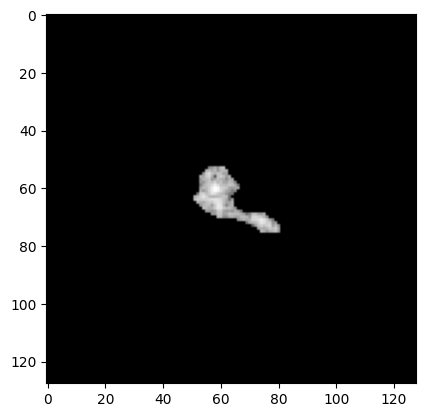

In [70]:
plt.imshow(test_ds[10][0][0].numpy(), cmap='gray', vmin = 0, vmax = 1)

In [71]:
train_ds.samples[118]

('/mnt/d/Users/Admin/Projects/dso/SAR_ML/data/DSO/MSTAR_sim_jul26/BRDM2_X3230gz15sqp00/BRDM2_asp340f_X3230gz15sqp00_dispimg_fdf6d9968.tif',
 0)

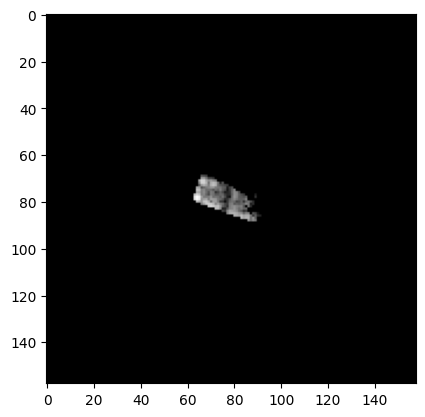

In [69]:
plt.imshow(train_ds[118][0][0].numpy(), cmap='gray', vmin = 0, vmax = 1)

# Centre Crop Training Data (158 to 128)

In [9]:
cropped_no_aug_synth_ds = DatasetFolderWithPath(
    "/mnt/d/Users/Admin/Projects/dso/SAR_ML/data/DSO/MSTAR_sim_jul26",
    extensions=(".tif",),
    transform=transforms.Compose([Magnitude(), CenterCrop(128), LogMapping(c=1000.0), NumpyToTensor3Channel()]),
    loader=dso_tiff_file_loader_fast_flipped
)

In [10]:
len(cropped_no_aug_synth_ds), len(no_aug_synth_ds)

(3600, 3600)

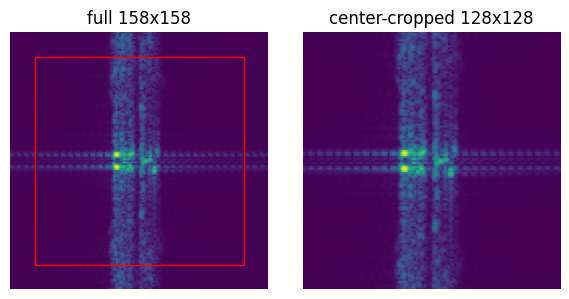

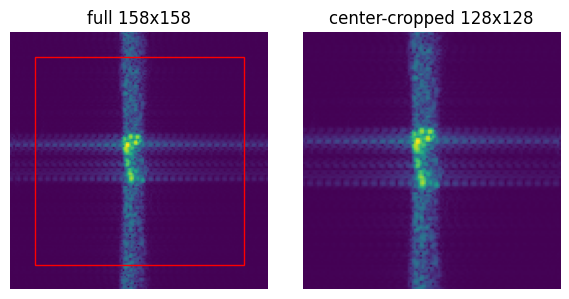

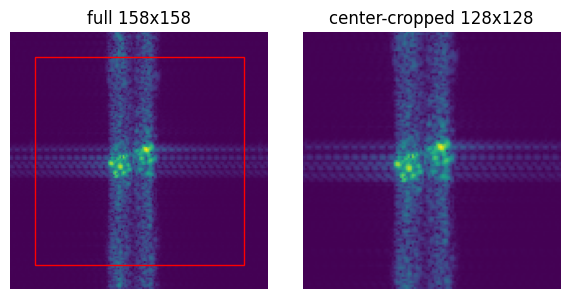

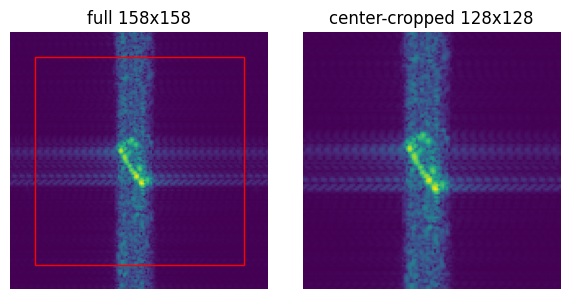

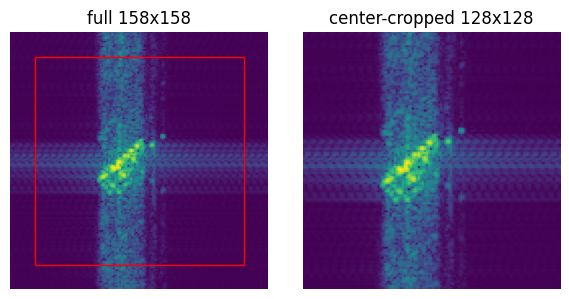

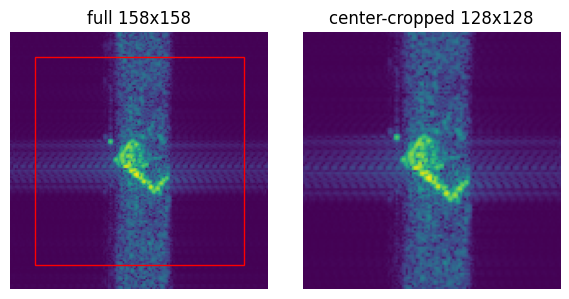

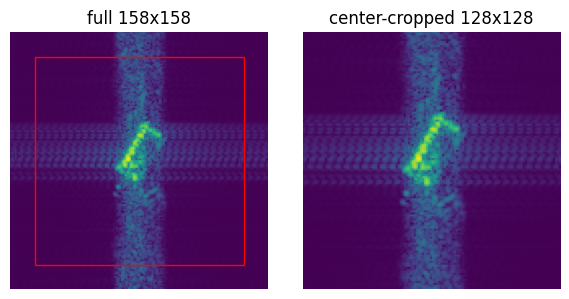

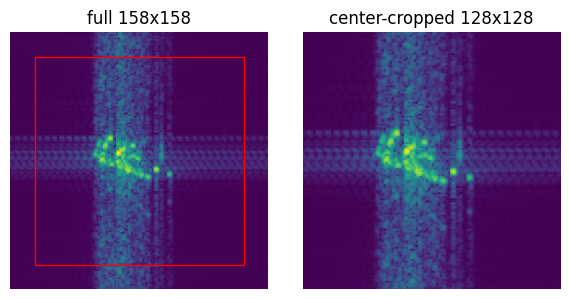

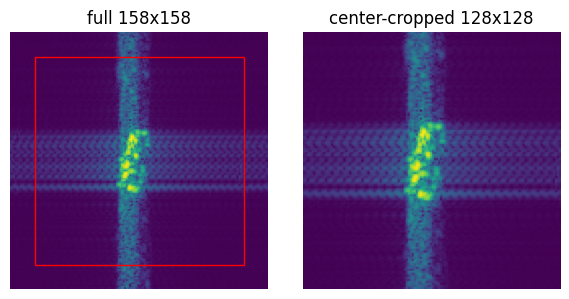

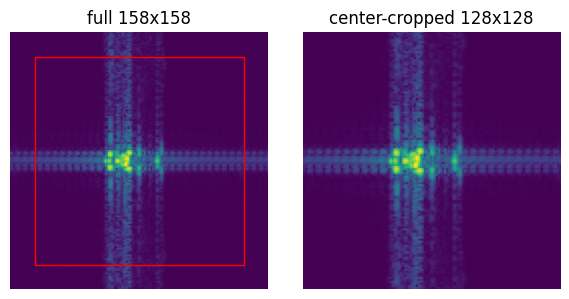

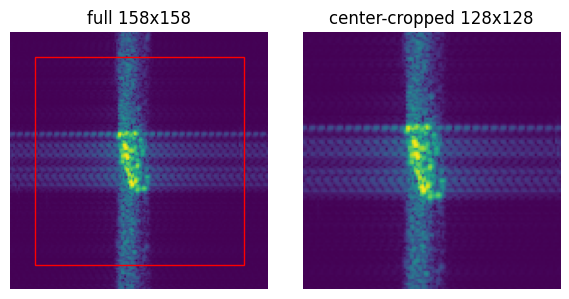

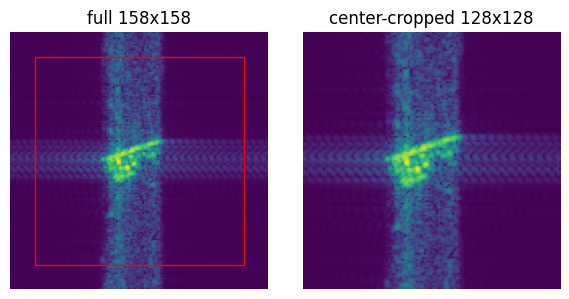

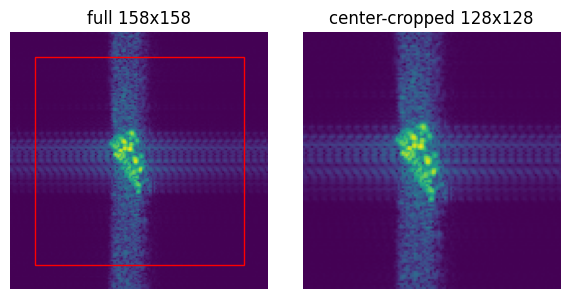

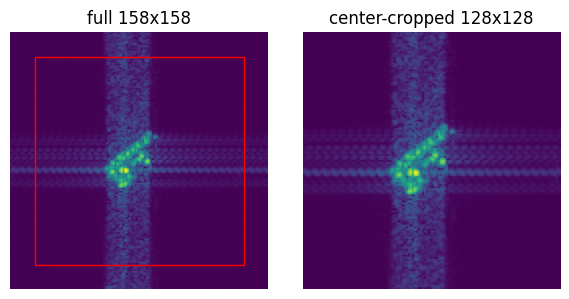

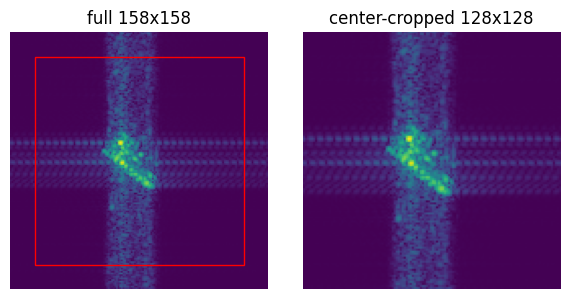

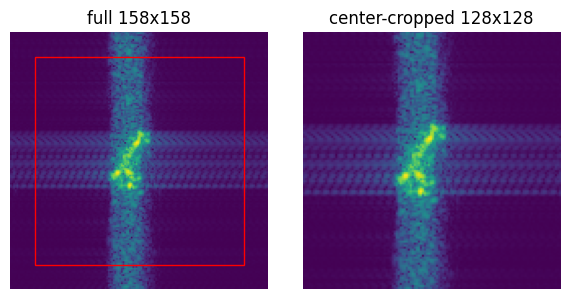

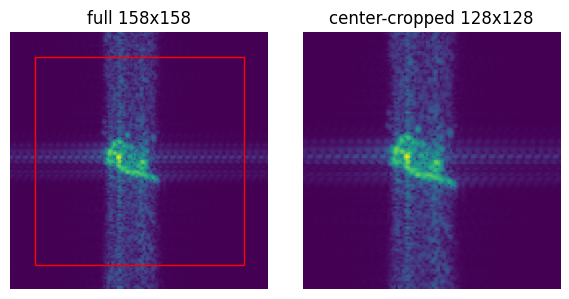

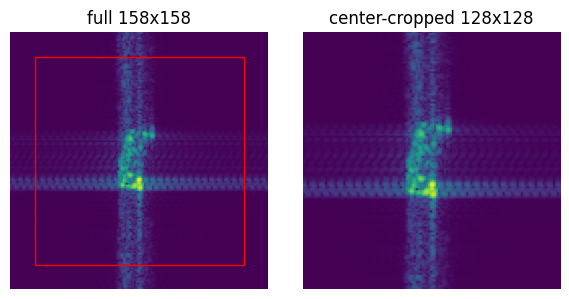

In [11]:
for i in range(0, len(no_aug_synth_ds), 200):
    
    fig, axes = plt.subplots(1, 2, figsize=(6, 3))
    axes[0].imshow(no_aug_synth_ds[i][0][0], vmin=0, vmax=1)
    axes[0].set_title('full 158x158')
    axes[0].add_patch(plt.Rectangle((15, 15), 128, 128, edgecolor='red', facecolor='none'))
    axes[1].imshow(cropped_no_aug_synth_ds[i][0][0], vmin=0, vmax=1)
    axes[1].set_title('center-cropped 128x128')
    for ax in axes:
        ax.axis('off')
    plt.tight_layout()
    plt.show()

In [12]:
synth_target_cache

{'/mnt/d/Users/Admin/Projects/dso/SAR_ML/data/DSO/MSTAR_sim_jul26/BRDM2_X3230gz15sqp00/BRDM2_asp000f_X3230gz15sqp00_dispimg_fdf6d9968.tif': array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], shape=(158, 158), dtype=uint8),
 '/mnt/d/Users/Admin/Projects/dso/SAR_ML/data/DSO/MSTAR_sim_jul26/BRDM2_X3230gz15sqp00/BRDM2_asp000g_X3230gz15sqp00_dispimg_fdf6d9968.tif': array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], shape=(158, 158), dtype=uint8),
 '/mnt/d/Users/Admin/Projects/dso/SAR_ML/data/DSO/MSTAR_sim_jul26/BRDM2_X3230gz15sqp00/BRDM2_asp001f_X3230gz15sqp00_dispimg_fdf6d9968.tif': array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 

In [13]:
synth_target_cache_cropped = {}
for path, mask in synth_target_cache.items():
    h, w = mask.shape
    t = 128
    top, left = (h - t) // 2, (w - t) // 2
    synth_target_cache_cropped[path] = mask[top:top+t, left:left+t]

In [14]:
cropped_seg_target_synth_ds = DatasetFolderWithPath(
    "/mnt/d/Users/Admin/Projects/dso/SAR_ML/data/DSO/MSTAR_sim_jul26",
    extensions=(".tif",),
    transform=transforms.Compose([
        Magnitude(),
        CenterCrop(128),
        LogMapping(c=1000.0),
        MaskedAugmentation(augmentation=identity, fill=0, mask_cache=synth_target_cache_cropped),
        NumpyToTensor3Channel()
    ]),
    loader=dso_tiff_file_loader_fast_flipped
)

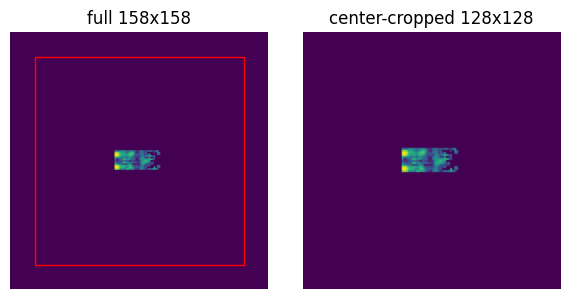

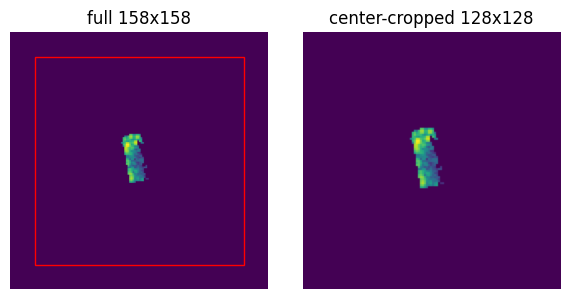

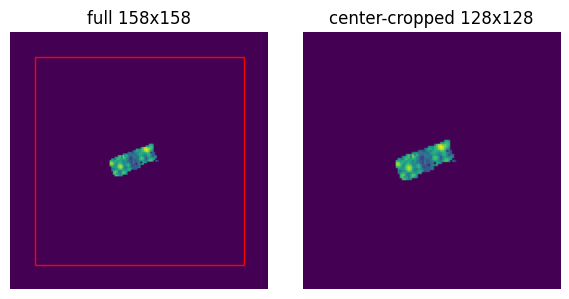

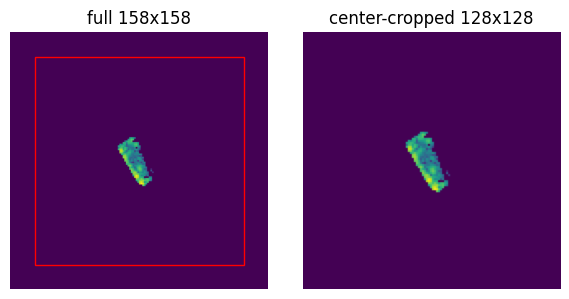

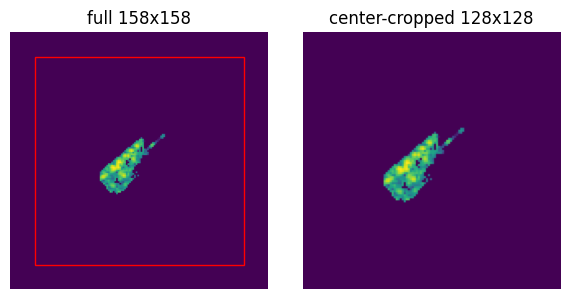

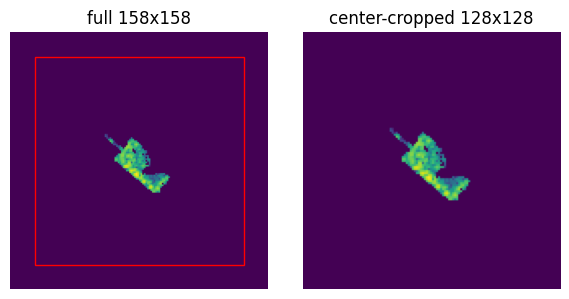

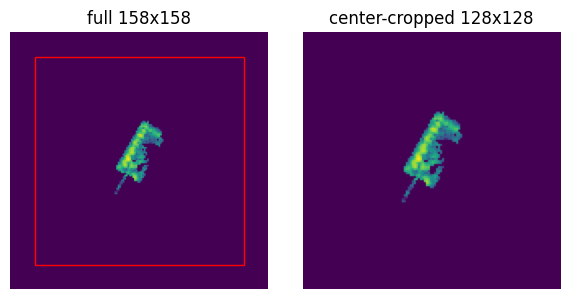

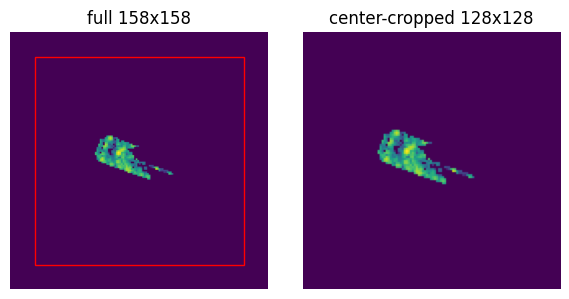

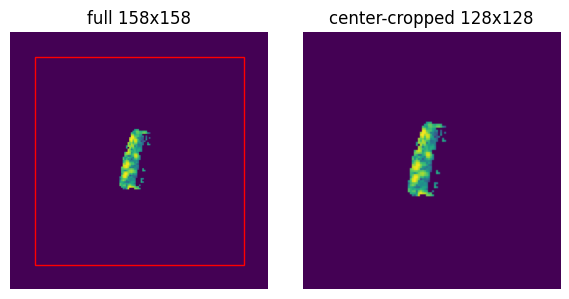

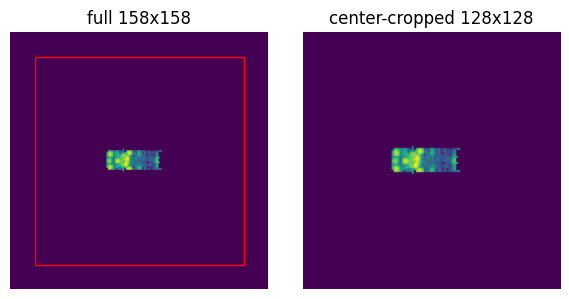

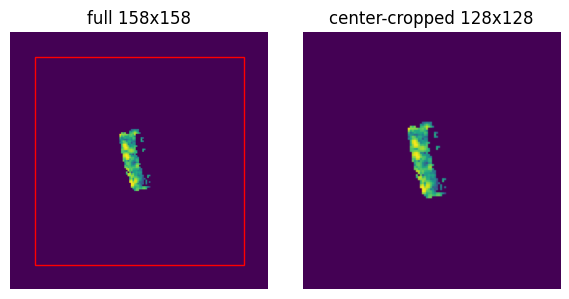

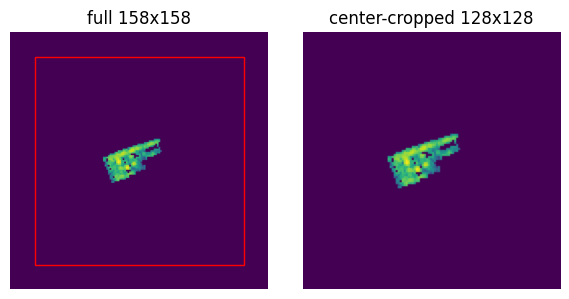

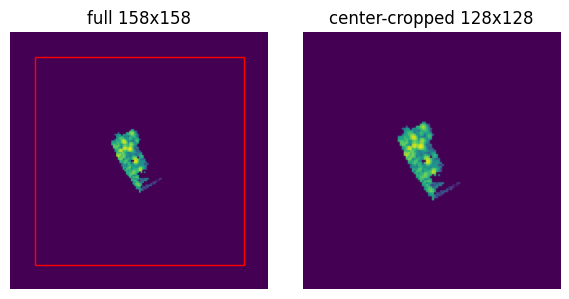

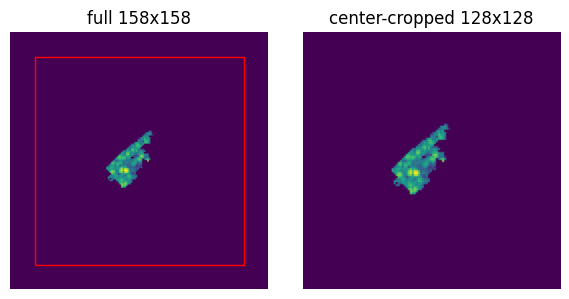

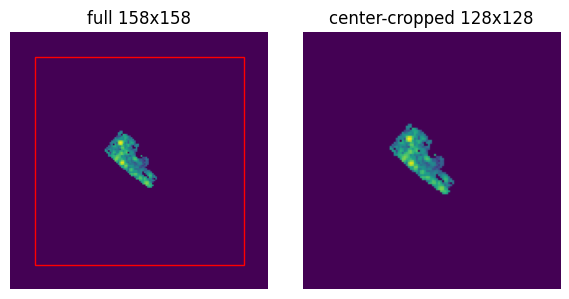

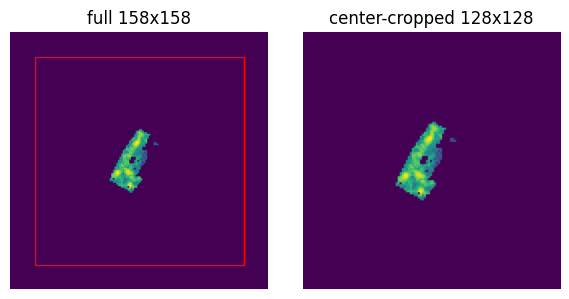

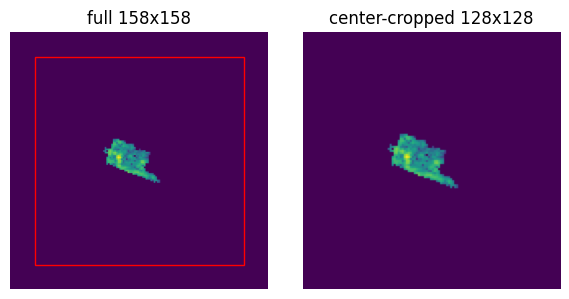

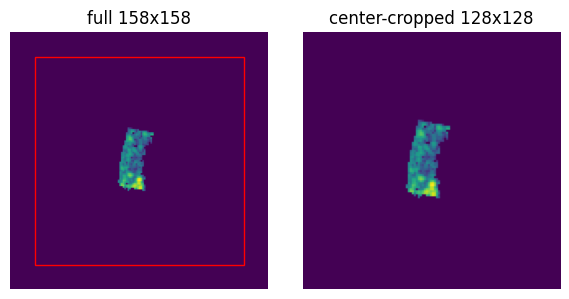

In [15]:
for i in range(0, len(no_aug_synth_ds), 200):
    
    fig, axes = plt.subplots(1, 2, figsize=(6, 3))
    axes[0].imshow(seg_target_synth_ds[i][0][0], vmin=0, vmax=1)
    axes[0].set_title('full 158x158')
    axes[0].add_patch(plt.Rectangle((15, 15), 128, 128, edgecolor='red', facecolor='none'))
    axes[1].imshow(cropped_seg_target_synth_ds[i][0][0], vmin=0, vmax=1)
    axes[1].set_title('center-cropped 128x128')
    for ax in axes:
        ax.axis('off')
    plt.tight_layout()
    plt.show()